In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [45]:
# cargo el modelo
modelo_rf = pickle.load(open('modelo_rf_optimizado.pkl', 'rb'))
# cargo el dataframe limpio
nba = pd.read_csv('nba_agrupado.csv')

#### Ahora voy a crear un dataframe donde pondre el nombre del jugador, la prediccion que hace el modelo de los puntos en la siguiente temporada y los puntos que de verdad tuvo de media.

In [56]:
# defino las variables que voy a usar para hacer las predicciones
variables = ['age', 'gp', 'pts_media_carrera', 'reb', 'ast', 'net_rating', 'ts_pct']
# selecciono las columnas que necesito para hacer las predicciones
X_todos = nba[variables]
# creo un dataframe para comparar las predicciones con los valores reales
comparativa = pd.DataFrame({
    'player_name': nba['player_name'].values,
    'prediccion': modelo_rf.predict(X_todos),
    'real': nba['pts_22_23'].values
})

In [47]:
# añado la columna error al dataframe comparativa, donde incluyo la diferencia entre predicción y dato real (en absoluto)
comparativa['error'] = abs(comparativa['prediccion'] - comparativa['real'])
# ordeno el dataframe por error absoluto
comparativa = comparativa.sort_values('error').reset_index(drop=True)
print("Estos son los 10 jugadores con menor error absoluto entre la predicción y el valor real:")
comparativa.head(10)

Estos son los 10 jugadores con menor error absoluto entre la predicción y el valor real:


,player_name,prediccion,real,error
0,Myles Turner,18.001644,18.0,0.001644
1,Wendell Carter Jr.,15.188315,15.2,0.011685
2,Lamar Stevens,5.280123,5.3,0.019877
3,Kevin Durant,29.073467,29.1,0.026533
4,Larry Nance Jr.,6.771023,6.8,0.028977
5,Jae Crowder,6.930019,6.9,0.030019
6,Udonis Haslem,3.931182,3.9,0.031182
7,Moses Brown,4.246375,4.3,0.053625
8,Theo Pinson,2.462655,2.4,0.062655
9,Kentavious Caldwell-Pope,10.736463,10.8,0.063537


In [48]:
# ordeno el dataframe por error absoluto
comparativa = comparativa.sort_values('error', ascending=False).reset_index(drop=True)
print("Estos son los 10 jugadores con mayor error absoluto entre la predicción y el valor real:")
comparativa.head(10)

Estos son los 10 jugadores con mayor error absoluto entre la predicción y el valor real:


,player_name,prediccion,real,error
0,Louis King,10.832269,20.0,9.167731
1,Spencer Dinwiddie,8.433674,17.3,8.866326
2,Blake Griffin,12.074486,4.1,7.974486
3,Anfernee Simons,13.733432,21.1,7.366568
4,Kevin Love,15.223270,8.2,7.023270
5,Terry Taylor,9.865519,2.9,6.965519
6,John Collins,19.949433,13.1,6.849433
7,Ben Simmons,13.324411,6.9,6.424411
8,T.J. Warren,13.847899,7.5,6.347899
9,Bojan Bogdanovic,15.401699,21.6,6.198301


In [49]:
pct = (comparativa['error'] < 3).sum() / len(comparativa) * 100
print(f'{pct:.1f}% de jugadores con error menor de 3 puntos')

80.9% de jugadores con error menor de 3 puntos


In [50]:
print(f'Error medio: {comparativa["error"].mean():.2f} puntos')

Error medio: 1.87 puntos


In [51]:
print(f'Media de puntos reales: {comparativa["real"].mean():.2f}')
print(f'Error medio: {comparativa["error"].mean():.2f}')
print(f'Error relativo: {comparativa["error"].mean() / comparativa["real"].mean() * 100:.1f}%')

Media de puntos reales: 9.86
Error medio: 1.87
Error relativo: 18.9%


#### La media de puntos es 9,86 y el error medio es 1,87. Esto significa que el modelo se equivoca de media un 18,9% respecto al valor real. Para un objetivo como los puntos, que tiene muchos factores en cuenta, no está mal la predicción.

In [52]:
estrellas = comparativa[comparativa['real'] >= 20]
print(f'Jugadores con más de 20 puntos de media: {len(estrellas)}')
print(f'Error medio: {estrellas["error"].mean():.2f}')
print(estrellas.sort_values('error'))

Jugadores con más de 20 puntos de media: 57
Error medio: 2.75
                 player_name  prediccion  real     error
447             Kevin Durant   29.073467  29.1  0.026533
431             Kyrie Irving   27.237674  27.1  0.137674
430             Devin Booker   27.656888  27.8  0.143112
423             Jamal Murray   20.184600  20.0  0.184600
421              Zach LaVine   24.610359  24.8  0.189641
397          Anthony Edwards   24.326645  24.6  0.273355
391             De'Aaron Fox   25.300555  25.0  0.300555
361            DeMar DeRozan   23.967520  24.5  0.532480
360                Ja Morant   25.659400  26.2  0.540600
358            Anthony Davis   26.449308  25.9  0.549308
329              Paul George   23.078970  23.8  0.721030
327              Tyler Herro   19.365721  20.1  0.734279
324          Zion Williamson   26.755579  26.0  0.755579
305         Donovan Mitchell   27.420136  28.3  0.879864
252              Bam Adebayo   19.100672  20.4  1.299328
236             Tyrese Max

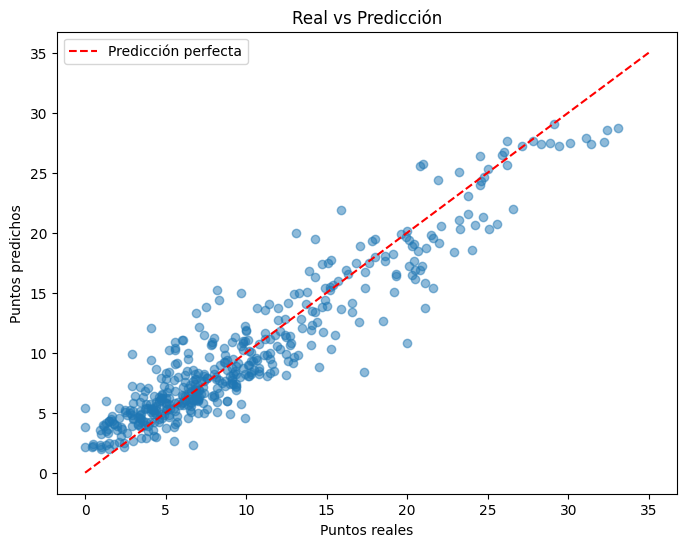

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(comparativa['real'], comparativa['prediccion'], alpha=0.5)
plt.plot([0, 35], [0, 35], color='red', linestyle='--', label='Predicción perfecta')
plt.xlabel('Puntos reales')
plt.ylabel('Puntos predichos')
plt.title('Real vs Predicción')
plt.legend()
plt.show()

#### Muy buena pinta. Los puntos siguen bien la diagonal roja, especialmente en la zona de 15-35 puntos donde están las estrellas. En la zona baja (0-10 puntos) hay más dispersión. Esto puede deberse a que los suplentes son más difíciles de predecir porque su rol varía mucho.

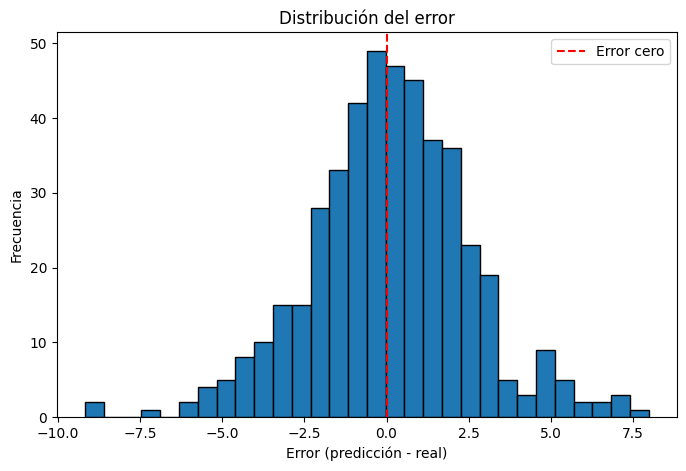

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(comparativa['prediccion'] - comparativa['real'], bins=30, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Error cero')
plt.xlabel('Error (predicción - real)')
plt.ylabel('Frecuencia')
plt.title('Distribución del error')
plt.legend()
plt.show()

#### El histograma está centrado en 0, que es buena señal. Pero la cola más larga hacia la izquierda (errores negativos), puede significar que el modelo tiende a sobreestimar, es decir, que está prediciendo más puntos de los que el jugador realmente anotó.

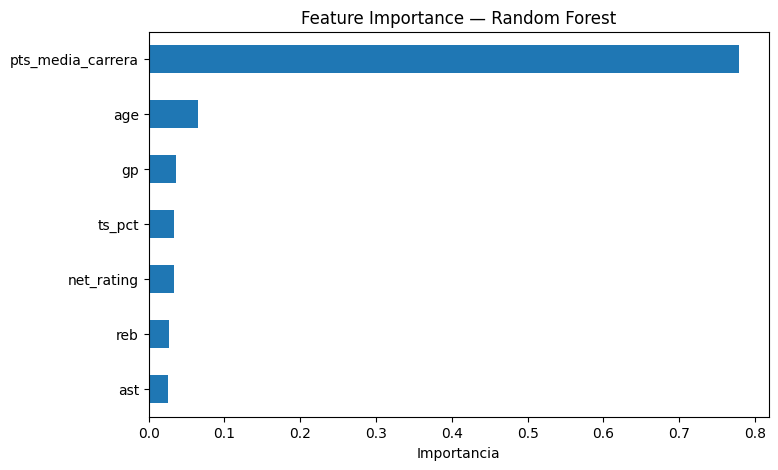

In [60]:
importancias = pd.Series(modelo_rf.feature_importances_, index=variables).sort_values()

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh')
plt.xlabel('Importancia')
plt.title('Feature Importance — Random Forest')
plt.show()

#### El modelo dice que el mejor predictor de cuánto anotará un jugador la próxima temporada es cuánto ha anotado en toda su carrera. Tiene mucho sentido.Esto también explica por qué el modelo funciona bien con estrellas (su media de carrera es muy estable) y peor con jugadores jóvenes o de rol variable (su media histórica no refleja bien lo que harán).